# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans 
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)



plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
print("Cantidad de valores nulos en users:")
print(users.isna().sum())


Cantidad de valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [11]:
print("Cantidad de valores nulos en usage:")
print(usage.isna().sum())

users[users['churn_date'].notna()].head(10)

users[['reg_date', 'churn_date']].head()

Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


,reg_date,churn_date
0,2022-01-01 00:00:00.000000000,NaN
1,2022-01-01 06:34:17.914478619,NaN
2,2022-01-01 13:08:35.828957239,NaN
3,2022-01-01 19:42:53.743435858,NaN
4,2022-01-02 02:17:11.657914478,NaN


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
Calculo del porcentaje de nulos y justificación de desiciones:

Total de usuarios: 4.000

city: 469/4000 = 11,73%: Dependiendo del análisis, podrían imputarse con la ciudad más frecuente o mantenerse como valores ausentes

churn_date: 3534/4000 = 88,35%: Aunque este porcentaje normalmente justificaría eliminar la columna, se recomienda conservarla porque los valores nulos podrían indicar clientes activos. Además, será necesario convertir la columna a formato de fecha antes de su análisis.


Total de registros de uso: 40.000

date: 50/40000 = 0,125%: Al ser una proporción muy baja recomiendo eliminarlos o mantenerlos como valores ausentes, ya que su impacto en el análisis será mínimo.

duration: 22076/40000 = 55,19%: Antes de imputar estos valores, es necesario verificar la relación con la columna type, ya que es probable que la duración solo aplique a los registros de llamadas y que los mensajes tengan este campo vacío de forma intencional.

length: 17896/40000 = 44,74%: De igual manera, recomiendo comprobar la relación con la columna type, ya que la longitud del mensaje probablemente solo exista para los registros de mensajes y sea normal que las llamadas presenten este campo vacío.




### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


La columna user_id: corresponde a un identificador único de los usuarios. No presenta valores nulos ni rangos anómalos y no requiere análisis estadístico, ya que se utiliza únicamente para identificar cada registro.

La columna age: presenta un valor mínimo de -999, que corresponde a un valor inválido o sentinel. Este dato afecta la media y la desviación estándar de la variable. Recomiendo reemplazar este valor por NaN y posteriormente decidir una estrategia de imputación o mantenerlo como dato faltante según el análisis.



In [13]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id corresponden a identificadores del registro y del usuario, respectivamente. No presentan valores fuera del rango esperado ni sentinels, por lo que pueden utilizarse para identificar registros y relacionar los datasets.


In [14]:
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"\nValores únicos de {columna}:")
    print(users[columna].value_counts(dropna=False))



Valores únicos de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


-La columna city presenta varias ciudades de México y Colombia; sin embargo, se identifican 469 valores nulos y una categoría denominada "?" con 96 registros, la cual corresponde a un valor inválido (sentinel). Recomiendo reemplazar "?" por NaN antes del análisis.

-La columna plan contiene únicamente dos categorías (Basico y Premium). No se observan errores de escritura ni valores inesperados, por lo que la información es consistente.


In [15]:

print(usage['type'].value_counts(dropna=False))


text    22092
call    17908
Name: type, dtype: int64


-La columna type contiene únicamente dos categorías (text y call). No presenta valores nulos ni categorías inconsistentes, por lo que no se identifican problemas de calidad en esta variable.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? age (-999) y city (?).
- ¿Qué acción tomarías? Reemplazarlos por NaN y revisar los valores 0 de duration y length antes de decidir si deben modificarse.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En reg_date se identifican registros correspondientes a los años 2022, 2023 y 2024, que están dentro del período de análisis. Sin embargo, también aparecen 40 registros del año 2026, los cuales están fuera del rango esperado y podrían corresponder a errores de captura o de registro.

In [19]:
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En date todos los registros pertenecen al año 2024, por lo que las fechas se encuentran dentro del período establecido para el análisis y no se observan años fuera de rango.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos): Sí, aparecen 40 registros del año 2026, que están fuera del período de análisis.
  
- ¿Qué harías con ellas? Revisarlas y, si se confirma que son errores, corregirlas o eliminarlas antes de continuar con el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Calcular la mediana excluyendo el sentinel
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar el sentinel por la mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar "?" por valores nulos
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)



Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas posteriores a 2024 como NA
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())



2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificar los nulos en duration según el tipo de actividad
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
pd.crosstab(usage['type'], usage['length'].isna())

length,False,True
type,,
call,12,17896
text,22092,0


In [25]:
# Verificar los nulos en length según el tipo de actividad
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

In [26]:
# Verificar los nulos en duration según el tipo de actividad
pd.crosstab(usage['type'], usage['duration'].isna())


duration,False,True
type,,
call,17908,0
text,16,22076


Se verificó que los valores nulos en las columnas duration y length dependen de la variable type. Las llamadas (call) contienen información en duration, mientras que los mensajes (text) presentan este campo como nulo, ya que no corresponde a ese tipo de actividad. De forma similar, los mensajes contienen información en length, mientras que las llamadas generalmente presentan este campo nulo. Por ello, estos valores faltantes se consideran MAR (Missing At Random) y no deben imputarse ni eliminarse, ya que forman parte del comportamiento esperado del dataset. No obstante, se identificaron 16 registros de tipo text con un valor en duration y 12 registros de tipo call con un valor en length, los cuales representan posibles inconsistencias que podrían revisarse en un análisis posterior.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)


usage_agg = (
    usage
    .groupby("user_id")
    .agg(
        total_calls=("is_call", "sum"),
        total_texts=("is_text", "sum"),
        total_minutes=("duration", "sum"),
        avg_call_duration=("duration", "mean"),
        avg_text_length=("length", "mean")
    )
    .reset_index()
)

total_texts=("is_text","sum")
total_minutes=("duration","sum")
avg_text_length=("length","mean")

# observar resultado
usage_agg.head(3)

,user_id,total_calls,total_texts,total_minutes,avg_call_duration,avg_text_length
0,10000,3,7,23.70,7.900,36.857143
1,10001,10,5,33.18,3.318,45.200000
2,10002,2,5,10.74,5.370,45.000000


In [28]:

usage_agg = usage_agg.rename(columns={
    "total_calls":"calls",
    "total_texts":"texts",
    "total_minutes":"minutes"
})
usage_agg.head(3)

,user_id,calls,texts,minutes,avg_call_duration,avg_text_length
0,10000,3,7,23.70,7.900,36.857143
1,10001,10,5,33.18,3.318,45.200000
2,10002,2,5,10.74,5.370,45.000000


In [29]:

user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
) 
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,calls,texts,minutes,avg_call_duration,avg_text_length
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,7.900000,36.857143
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,3.318000,45.200000
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,5.370000,45.000000
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,2.996667,48.181818
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,2.670000,57.250000


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Seleccionar las columnas numéricas relevantes
numeric_columns = [
    'age',
    'calls',
    'texts',
    'minutes',
    'avg_call_duration',
    'avg_text_length'
]

# Resumen estadístico
user_profile[numeric_columns].describe()


,age,calls,texts,minutes,avg_call_duration,avg_text_length
count,4000.000000,3999.000000,3999.000000,3999.000000,3958.000000,3981.000000
mean,48.136000,4.478120,5.524381,23.317054,5.229795,52.249661
std,17.689919,2.144238,2.358416,18.168095,3.892719,28.914064
min,18.000000,0.000000,0.000000,0.000000,0.020000,0.000000
25%,33.000000,3.000000,4.000000,11.120000,3.175000,44.000000
50%,48.000000,4.000000,5.000000,19.780000,4.650000,50.333333
75%,63.000000,6.000000,7.000000,31.415000,6.421563,56.181818
max,79.000000,15.000000,17.000000,155.690000,120.000000,764.000000


In [31]:

# Distribución porcentual de los planes
user_profile['plan'].value_counts(normalize=True) * 100



Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

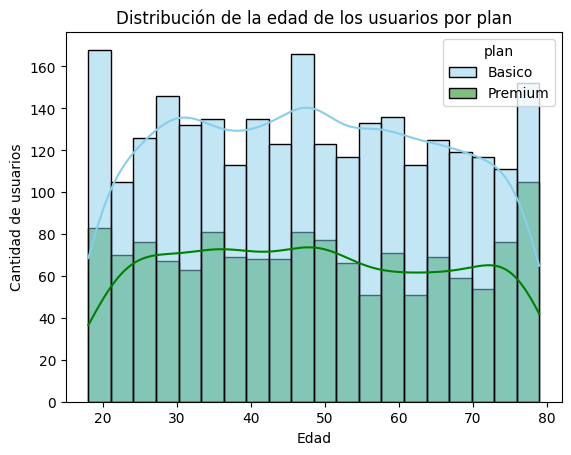

In [32]:

# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)

plt.title('Distribución de la edad de los usuarios por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [33]:
user_profile.groupby('plan')['age'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
plan,,,,
Basico,48.041618,48.0,18.0,79.0
Premium,48.310320,48.0,18.0,79.0


-Tipo de distribución: la variable age es aproximadamente simétrica, ya que la media (48,14) y la mediana (48) son prácticamente iguales.

-La distribución de la edad permite comparar el perfil de los usuarios de los planes Básico y Premium. En términos generales, la edad presenta una distribución relativamente equilibrada alrededor de la mediana de 48 años, aunque pueden observarse diferencias en la concentración de usuarios entre ambos planes. 


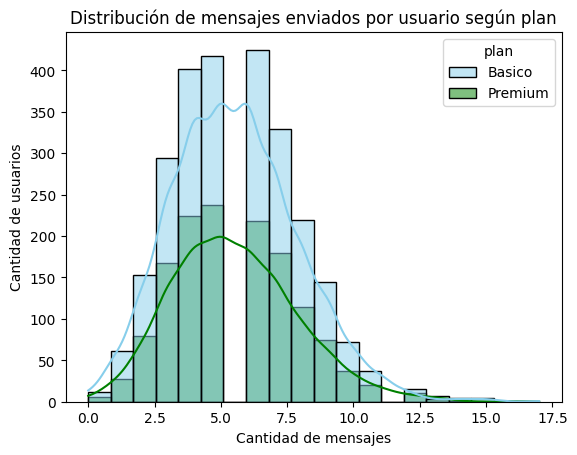

In [34]:
# Histograma para visualizar la cantidad de mensajes

sns.histplot(
    data=user_profile,
    x='texts',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)

plt.title('Distribución de mensajes enviados por usuario según plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


In [35]:
user_profile.groupby('plan')['texts'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
plan,,,,
Basico,5.527756,5.0,0.0,17.0
Premium,5.518149,5.0,0.0,16.0


In [36]:
user_profile.groupby('plan')['texts'].mean().sort_values(ascending=False)

plan
Basico     5.527756
Premium    5.518149
Name: texts, dtype: float64

-Tipo de distribución: sesgada a la derecha, debido a que existen valores altos que se alejan de la concentración principal. En los datos del notebook, el promedio es 5,52 mensajes, mientras que el máximo llega a 17.

-La distribución muestra concentración en valores relativamente bajos y una cola hacia valores superiores, por lo que existen algunos usuarios que envían una cantidad considerablemente mayor de mensajes que la mayoría.

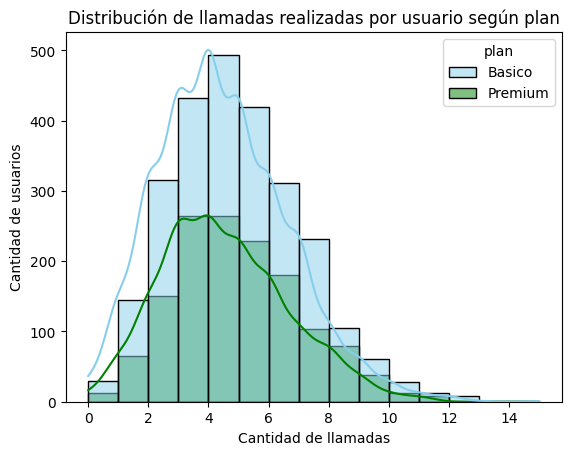

In [37]:
# Histograma para visualizar la cantidad de llamadas

sns.histplot(
    data=user_profile,
    x='calls',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15,
    kde=True
)

plt.title('Distribución de llamadas realizadas por usuario según plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


In [38]:
user_profile.groupby('plan')['calls'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
plan,,,,
Basico,4.456438,4.0,0.0,15.0
Premium,4.518149,4.0,0.0,11.0


In [39]:
user_profile.groupby('plan')['calls'].mean().sort_values(ascending=False)

plan
Premium    4.518149
Basico     4.456438
Name: calls, dtype: float64

In [40]:
user_profile['calls'].mean()

4.478119529882471

-Tipo de distribución: ligeramente sesgada a la derecha, porque la media (4,48) es superior a la mediana (4) y el máximo alcanza 15 llamadas.

-Los usuarios Premium realizan ligeramente más llamadas en promedio (4.52) que los usuarios Básico (4.46). Sin embargo, la diferencia es muy pequeña y ambos planes presentan una mediana de 4 llamadas, por lo que no se observa una diferencia significativa en la cantidad de llamadas según el plan. La distribución presenta un sesgo hacia la derecha, debido a que existen usuarios que realizan una cantidad de llamadas considerablemente mayor que la mayoría. En general, considerando todos los usuarios independientemente del plan, el promedio es de aproximadamente 4.48 llamadas por usuario.

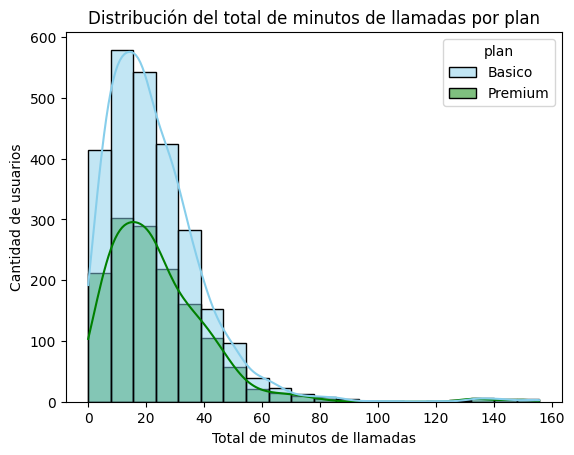

In [41]:
# Histograma para visualizar el total de minutos de llamadas

sns.histplot(
    data=user_profile,
    x='minutes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)

plt.title('Distribución del total de minutos de llamadas por plan')
plt.xlabel('Total de minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


In [42]:
user_profile.groupby('plan')['minutes'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
plan,,,,
Basico,22.905436,19.535,0.0,155.69
Premium,24.077011,20.640,0.0,153.06


In [43]:
user_profile.groupby('plan')['minutes'].mean().sort_values(ascending=False)

plan
Premium    24.077011
Basico     22.905436
Name: minutes, dtype: float64

-Tipo de distribución: sesgada a la derecha. Esto se evidencia porque la media (23,32) es mayor que la mediana (19,78) y existe un máximo de 155,69 minutos.
-Los usuarios Premium presentan un consumo ligeramente mayor de minutos de llamadas que los Básico (24,08 vs. 22,91 minutos en promedio). Sin embargo, la diferencia es pequeña. En ambos planes la distribución está sesgada a la derecha, debido a la presencia de usuarios con consumos muy superiores al habitual, alcanzando máximos de aproximadamente 153–156 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

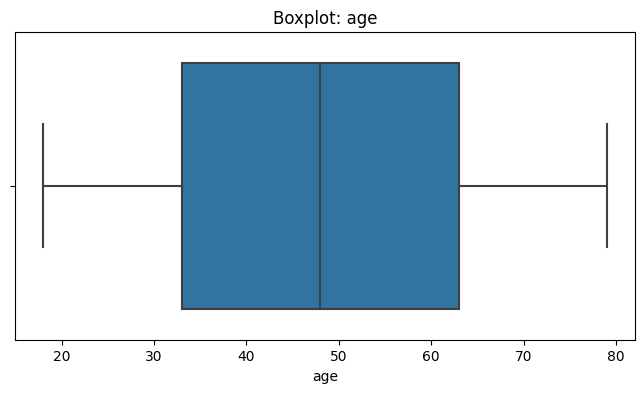

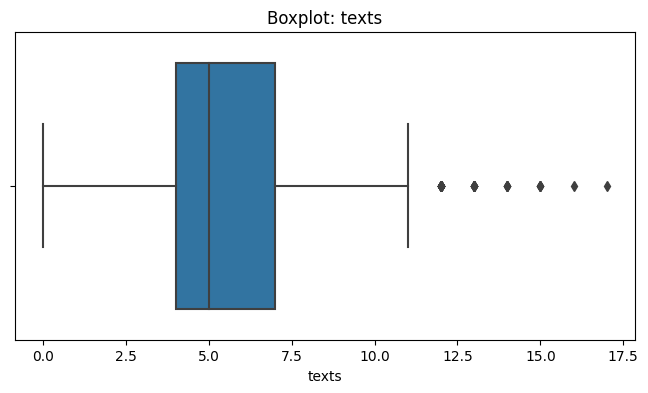

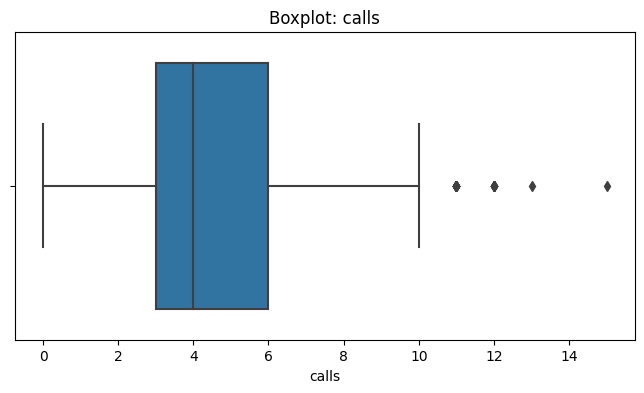

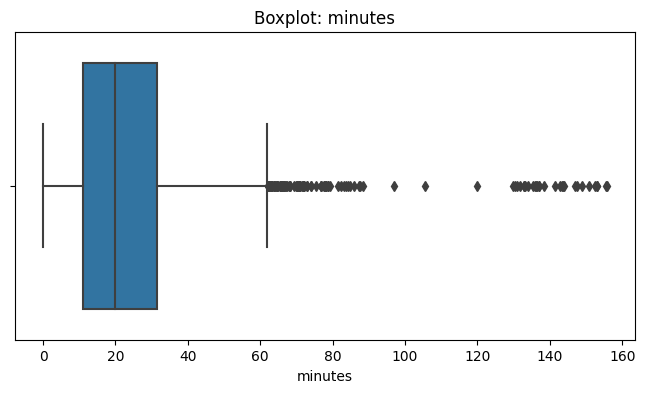

In [44]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'texts', 'calls', 'minutes']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=user_profile,
        x=col
    )
    
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()



- Age: No presenta outliers. El 50 % central de los usuarios se encuentra entre 33 y 63 años y los valores observados, entre 18 y 79 años, se encuentran dentro del rango esperado según el método IQR.

- Cantidad de mensajes (texts): Presenta outliers en la parte superior. La mayoría de los usuarios envía una cantidad relativamente baja de mensajes, pero existen usuarios con valores superiores al límite establecido por el método IQR, llegando hasta 17 mensajes.

- Cantidad de llamadas (calls): Presenta outliers superiores. La mayoría de los usuarios realiza pocas llamadas, pero algunos usuarios alcanzan hasta 15 llamadas, superando el límite superior calculado mediante IQR.

- Total de minutos de llamadas (minutes): Presenta outliers superiores de forma más evidente. La mayoría de los usuarios concentra su consumo en valores bajos y medios, mientras que algunos usuarios alcanzan valores muy elevados, llegando hasta 155.69 minutos.

- Conclusión: El análisis mediante boxplots permitió identificar que age no presenta valores atípicos relevantes, mientras que texts, calls y especialmente minutes presentan outliers superiores. Estos valores no serán eliminados porque representan posibles patrones reales de consumo intensivo de los usuarios y pueden aportar información valiosa para la segmentación y toma de decisiones comerciales de ConnectaTel. Por lo tanto, se conservarán para el análisis posterior.

In [45]:

# Calcular límites superiores con el método IQR

columnas_limites = ['texts', 'calls', 'minutes']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    print(f'\nVariable: {col}')
    print(f'Q1: {Q1:.2f}')
    print(f'Q3: {Q3:.2f}')
    print(f'IQR: {IQR:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Máximo observado: {user_profile[col].max():.2f}')



Variable: texts
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite superior: 11.50
Máximo observado: 17.00

Variable: calls
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite superior: 10.50
Máximo observado: 15.00

Variable: minutes
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite superior: 61.86
Máximo observado: 155.69


In [46]:
columnas_limites = ['texts', 'calls', 'minutes']

user_profile[columnas_limites].describe()



,texts,calls,minutes
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


- Cantidad de mensajes (texts): Recomiendo mantener los outliers, porque los valores altos pueden representar usuarios con un nivel de comunicación elevado y no necesariamente errores en los datos. Eliminarlos podría ocultar información relevante sobre los clientes de alto consumo.

- Cantidad de llamadas (calls): Recomiendo mantener los outliers, ya que las llamadas superiores al límite IQR pueden corresponder a usuarios que utilizan con mayor frecuencia el servicio. No hay evidencia de que estos valores sean registros incorrectos.

- Total de minutos de llamadas (minutes): Recomiendo mantener los outliers, debido a que los valores elevados pueden representar usuarios con un consumo intensivo del servicio. El máximo de 155.69 minutos es alto respecto a la mayoría de los usuarios, pero sigue siendo un valor posible dentro del comportamiento de uso y no debe eliminarse sin evidencia de error.

- | Variable  | ¿Outliers? | Límite superior aprox. | Máximo | Decisión     |
| --------- | ------------ | ---------------------: | -----: | ------------ |
| `age`     | ❌ No       |                    108 |     79 | **Mantener** |
| `texts`   | ✅ Sí       |                  11.50 |     17 | **Mantener** |
| `calls`   | ✅ Sí       |                  10.50 |     15 | **Mantener** |
| `minutes` | ✅ Sí       |                  61.86 | 155.69 | **Mantener** |


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = np.select(
    [
        (user_profile['calls'] < 5) & (user_profile['texts'] < 5),
        (user_profile['calls'] < 10) & (user_profile['texts'] < 10)
    ],
    [
        'Bajo uso',
        'Uso medio'
    ],
    default='Alto uso'
)


In [48]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,calls,texts,minutes,avg_call_duration,avg_text_length,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,7.900000,36.857143,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,3.318000,45.200000,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,5.370000,45.000000,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,2.996667,48.181818,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,2.670000,57.250000,Bajo uso


In [49]:
# Cantidad de usuarios por grupo

user_profile['grupo_uso'].value_counts()


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [50]:
# Porcentaje de usuarios por grupo

user_profile['grupo_uso'].value_counts(normalize=True).mul(100).round(2)


Uso medio    73.58
Bajo uso     19.45
Alto uso      6.98
Name: grupo_uso, dtype: float64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [51]:
# Crear columna grupo_edad

user_profile['grupo_edad'] = np.select(
    [
        user_profile['age'] < 30,
        user_profile['age'] < 60
    ],
    [
        'Joven',
        'Adulto'
    ],
    default='Adulto Mayor'
)


In [52]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,calls,texts,minutes,avg_call_duration,avg_text_length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,7.900000,36.857143,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,3.318000,45.200000,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,5.370000,45.000000,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,2.996667,48.181818,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,2.670000,57.250000,Bajo uso,Adulto Mayor


In [53]:
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [55]:
user_profile['grupo_edad'].value_counts(normalize=True).mul(100).round(2)

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

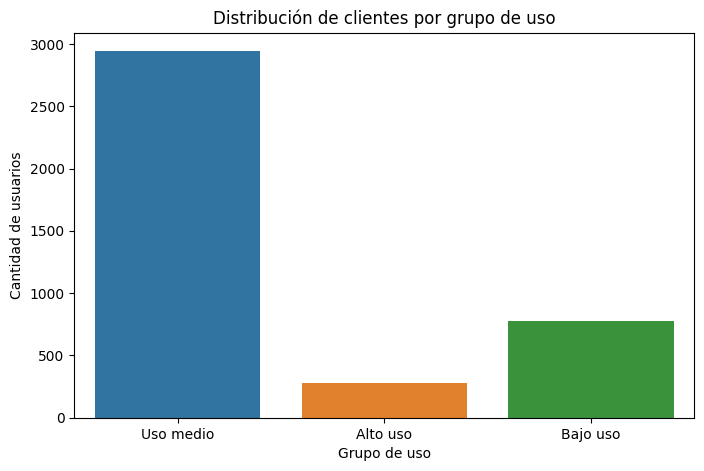

In [56]:
# Visualización de los segmentos por uso

plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()



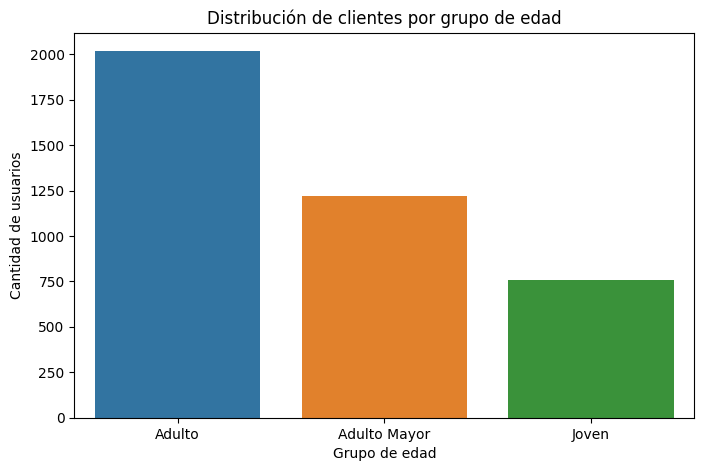

In [58]:

# Visualización de los segmentos por edad

plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la preparación de los datos fue necesario revisar y corregir problemas de calidad y formato para poder realizar correctamente el análisis. También se revisaron los valores extremos antes de decidir si debían eliminarse. Los outliers encontrados en las variables de uso se conservaron porque pueden representar comportamientos reales de clientes con un consumo elevado.


🔍 **Segmentos por Edad**
Los clientes fueron clasificados en tres grupos: Joven (menores de 30 años), Adulto (entre 30 y 59 años) y Adulto Mayor (60 años o más). Esta segmentación permite identificar diferencias en el perfil de los clientes y facilita la creación de estrategias comerciales dirigidas a las necesidades de cada grupo.


📊 **Segmentos por Nivel de Uso**
Los clientes fueron clasificados como Bajo uso, Uso medio y Alto uso según la cantidad de llamadas y mensajes. Los usuarios de Alto uso representan una oportunidad comercial importante, ya que presentan una mayor intensidad de utilización de los servicios. Los usuarios de Uso medio también pueden ser un segmento atractivo para estrategias de fidelización y migración hacia planes superiores.


➡️ Esto sugiere que ConnectaTel puede mejorar su estrategia comercial combinando edad y nivel de uso para ofrecer planes y promociones más personalizados. Los clientes de mayor consumo podrían beneficiarse de planes con mayor capacidad, mientras que los usuarios de menor consumo podrían recibir alternativas más económicas y ajustadas a sus necesidades.


💡 **Recomendaciones**

-Crear o fortalecer planes diferenciados según el nivel de uso.
-Ofrecer planes de mayor capacidad a los clientes de Alto uso, especialmente aquellos con consumos elevados de minutos, llamadas o mensajes.
-Implementar estrategias de upselling para usuarios de Uso medio que puedan pasar a un plan superior.
-Ofrecer planes económicos para clientes de Bajo uso, buscando aumentar la fidelización.
-Combinar grupo_edad + grupo_uso para crear campañas comerciales más personalizadas.
-Mantener los outliers de llamadas, mensajes y minutos, ya que pueden representar clientes reales de alto consumo y oportunidades comerciales importantes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`